# DWA - Dynamic Window Approach

## Setup
Install required dependencies for interactive widgets

In [1]:
!pip install ipywidgets --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries
Import essential libraries for numerical computation, visualization, and animation

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
from matplotlib import animation
from IPython.display import HTML, display, clear_output
import ipywidgets as widgets

## Configuration
Define robot parameters and DWA algorithm settings including speed limits, acceleration, and cost weights

In [3]:
class Config:
    def __init__(self):
        self.max_speed = 1.5
        self.min_speed = -0.2
        self.max_yaw_rate = 60.0 * math.pi / 180.0
        self.max_accel = 0.6
        self.max_delta_yaw_rate = 60.0 * math.pi / 180.0
        self.v_reso = 0.1
        self.yaw_rate_reso = 2.0 * math.pi / 180.0
        self.dt = 0.2
        self.predict_time = 3.0
        self.to_goal_cost_gain = 1.0
        self.speed_cost_gain = 0.2
        self.obstacle_cost_gain = 0.8
        self.robot_radius = 0.5

cfg = Config()

## Motion Model
Update robot position and orientation based on velocity and steering angle commands

In [4]:
def motion(x, u, dt):
    x[0] += u[0] * math.cos(x[2]) * dt
    x[1] += u[0] * math.sin(x[2]) * dt
    x[2] += u[1] * dt
    x[3] = u[0]
    x[4] = u[1]
    return x


## DWA Algorithm Functions
Implement the Dynamic Window Approach including dynamic window calculation, trajectory prediction, and cost evaluation functions

In [5]:
def calc_dynamic_window(x, cfg):
    Vs = [cfg.min_speed, cfg.max_speed, -cfg.max_yaw_rate, cfg.max_yaw_rate]
    Vd = [
        x[3] - cfg.max_accel * cfg.dt,
        x[3] + cfg.max_accel * cfg.dt,
        x[4] - cfg.max_delta_yaw_rate * cfg.dt,
        x[4] + cfg.max_delta_yaw_rate * cfg.dt
    ]
    dw = [
        max(Vs[0], Vd[0]),
        min(Vs[1], Vd[1]),
        max(Vs[2], Vd[2]),
        min(Vs[3], Vd[3])
    ]
    return dw

def predict_trajectory(x_init, v, y, cfg):
    x = copy.deepcopy(x_init)
    traj = [x[:]]
    time = 0
    while time <= cfg.predict_time:
        x = motion(x, [v, y], cfg.dt)
        traj.append(x[:])
        time += cfg.dt
    return traj

def calc_to_goal_cost(traj, goal):
    dx = goal[0] - traj[-1][0]
    dy = goal[1] - traj[-1][1]
    return math.hypot(dx, dy)

def calc_obstacle_cost(traj, ob, cfg):
    min_r = float("inf")
    for x in traj:
        for ox, oy in ob:
            dist = math.hypot(x[0] - ox, x[1] - oy)
            if dist <= cfg.robot_radius:
                return float("Inf")
            if dist < min_r:
                min_r = dist
    return 1.0 / min_r

def dwa_control(x, cfg, goal, ob):
    dw = calc_dynamic_window(x, cfg)
    min_cost = float("inf")
    best_u = [0.0, 0.0]
    best_traj = [x]

    for v in np.arange(dw[0], dw[1], cfg.v_reso):
        for y in np.arange(dw[2], dw[3], cfg.yaw_rate_reso):
            traj = predict_trajectory(x, v, y, cfg)
            to_goal_cost = cfg.to_goal_cost_gain * calc_to_goal_cost(traj, goal)
            speed_cost = cfg.speed_cost_gain * (cfg.max_speed - traj[-1][3])
            ob_cost = cfg.obstacle_cost_gain * calc_obstacle_cost(traj, ob, cfg)
            final_cost = to_goal_cost + speed_cost + ob_cost

            if final_cost < min_cost:
                min_cost = final_cost
                best_u = [v, y]
                best_traj = traj

    return best_u, best_traj

## Visualization
Create an animation function that renders robot trajectory, goal position, and obstacles

In [6]:
def animate_dwa(traj_history, goal, ob):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(goal[0], goal[1], 'rx', label='Goal')
    ax.plot(*zip(*ob), 'ok', label='Obstacles')
    robot_dot, = ax.plot([], [], 'bo', markersize=8, label='Robot')
    path_line, = ax.plot([], [], 'b-', linewidth=2, label='Path')
    heading_arrow = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='blue')

    def init():
        ax.set_xlim(-2, 12)
        ax.set_ylim(-2, 12)
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend()
        return robot_dot, path_line, heading_arrow

    def update(frame):
        x_vals = [s[0] for s in traj_history[:frame+1]]
        y_vals = [s[1] for s in traj_history[:frame+1]]
        yaw = traj_history[frame][2]
        robot_dot.set_data([x_vals[-1]], [y_vals[-1]])
        path_line.set_data(x_vals, y_vals)
        dx = 0.4 * math.cos(yaw)
        dy = 0.4 * math.sin(yaw)
        heading_arrow.set_offsets([x_vals[-1], y_vals[-1]])
        heading_arrow.set_UVC(dx, dy)
        return robot_dot, path_line, heading_arrow

    ani = animation.FuncAnimation(fig, update, frames=len(traj_history), init_func=init,
                                  blit=True, interval=100, repeat=False)
    return HTML(ani.to_jshtml())


## Simulation
Run the DWA simulation with initial conditions and animate the robot's path to the goal

Goal reached!


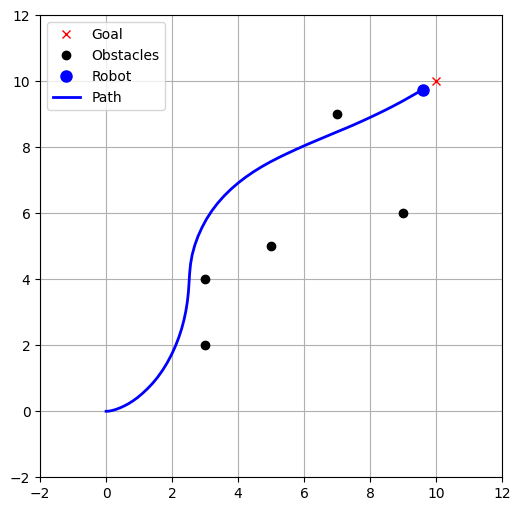

In [7]:
# Run simulation
x = [0.0, 0.0, 0.0, 0.0, 0.0]
goal = [10.0, 10.0]
ob = np.array([[3, 2], [3, 4], [5, 5], [9, 6], [7, 9]])
traj_history = [x[:]]

for _ in range(200):
    u, _ = dwa_control(x, cfg, goal, ob)
    x = motion(x, u, cfg.dt)
    traj_history.append(x[:])
    if math.hypot(x[0] - goal[0], x[1] - goal[1]) <= cfg.robot_radius:
        print("Goal reached!")
        break

display(animate_dwa(traj_history, goal, ob))
